In [26]:
import RF_Track as rft
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
from pathlib import Path

from aux import plot_phase_space, plot_lattice, plot_solenoid_field_lattice
from data import parser
from structure import create_lebt

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path


    

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Initial Bunch

N: 14875, Mass: 11174.9 MeV, Energy: 0.182629 MeV, Frequency: 749.48 MHz, Current: 2.74285e-06 A, Charge: 6 e


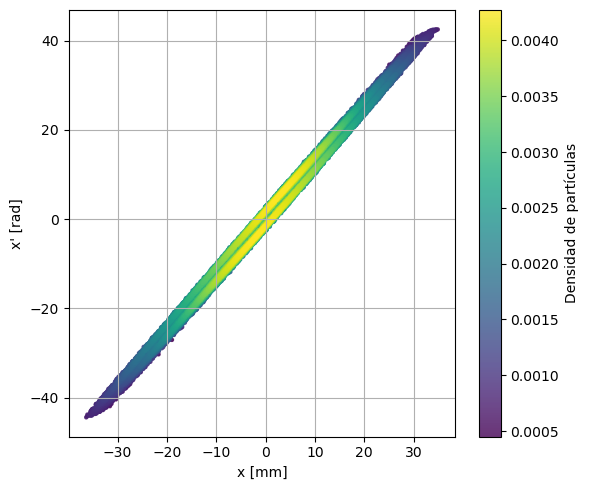

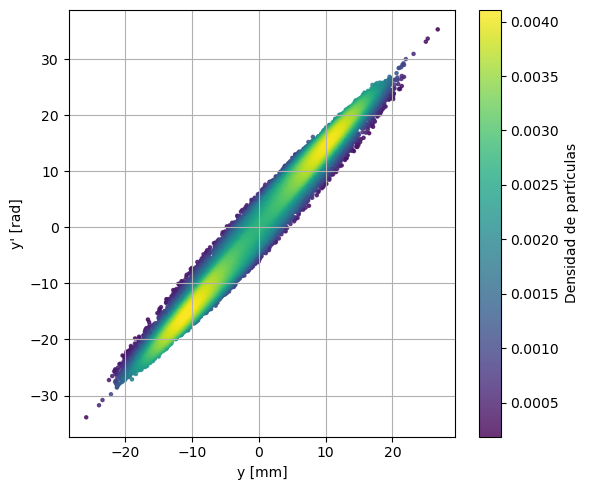

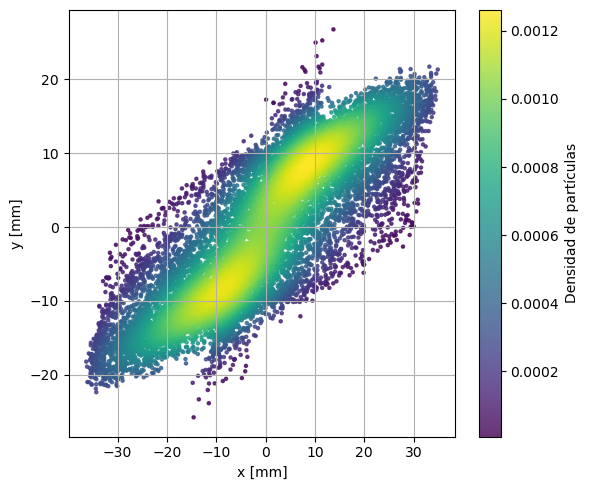

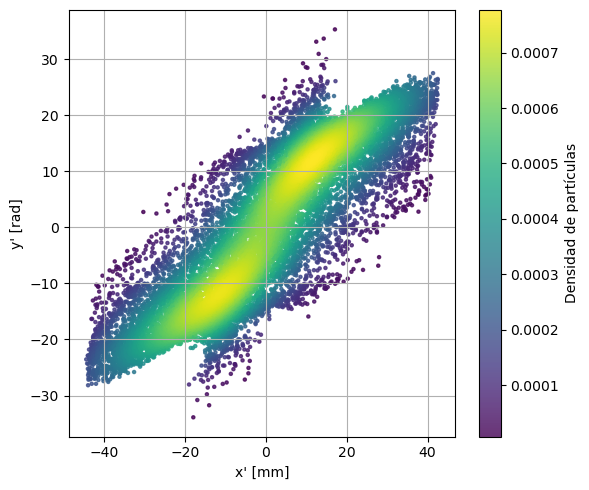

In [27]:
B0 = parser()
M0 = B0.get_phase_space('%x %xp %y %yp %N')

x  = M0[:,0]
xp = M0[:,1]
y  = M0[:,2]
yp = M0[:,3]
No = M0[:,4]


plot_phase_space(x, xp, "x [mm]", "x' [rad]")
plot_phase_space(y, yp, "y [mm]", "y' [rad]")
plot_phase_space(x, y,  "x [mm]", "y [mm]")
plot_phase_space(xp, yp, "x' [mm]", "y' [rad]")



### LEBT

K1_dip: 0.0 1/m^2, Bfield_dip: 0.08879569897271715 T
B:0.08879569897271715 T


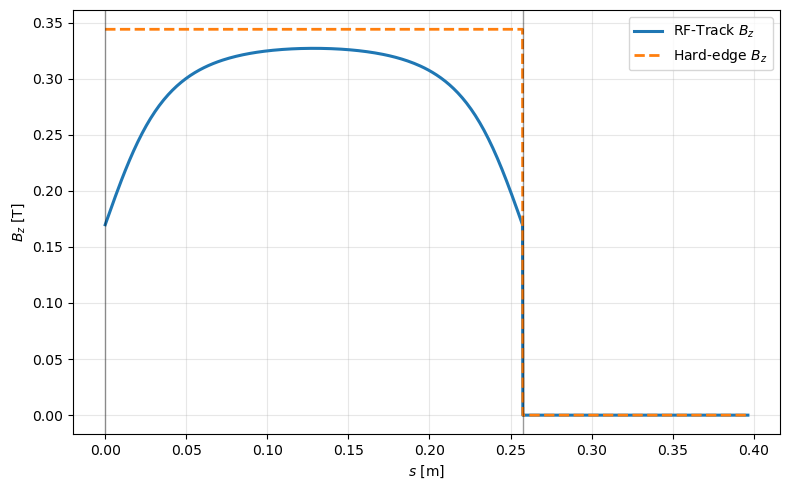

RF-Track final values
---------------------

X-X'
emit_x      = 0.218042 mm mrad
Twiss beta_x = 0.010936 mm/mrad
Twiss alpha_x = 0.050501
sigma_x     = 0.645820 mm
sigma_xp    = 59125.970133 mrad

Y-Y'
emit_y      = 0.072888 mm mrad
Twiss beta_y = 0.012936 mm/mrad
Twiss alpha_y = -1.281789
sigma_y     = 0.406107 mm
sigma_yp    = 51031.523538 mrad

4D
emit4D      = 4.229200e-03 (mm mrad)^2


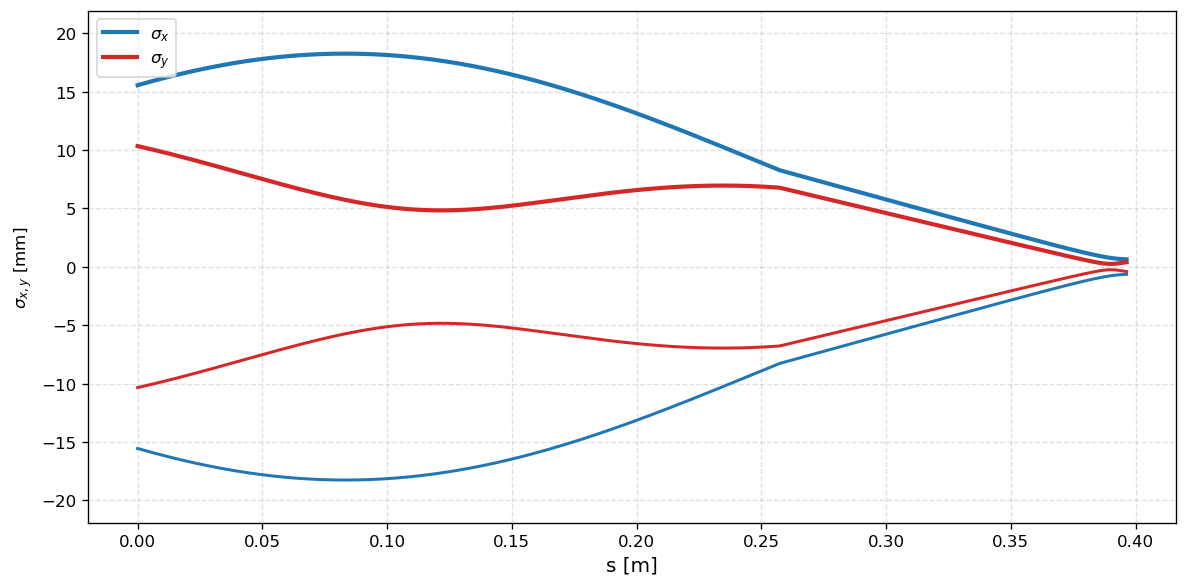

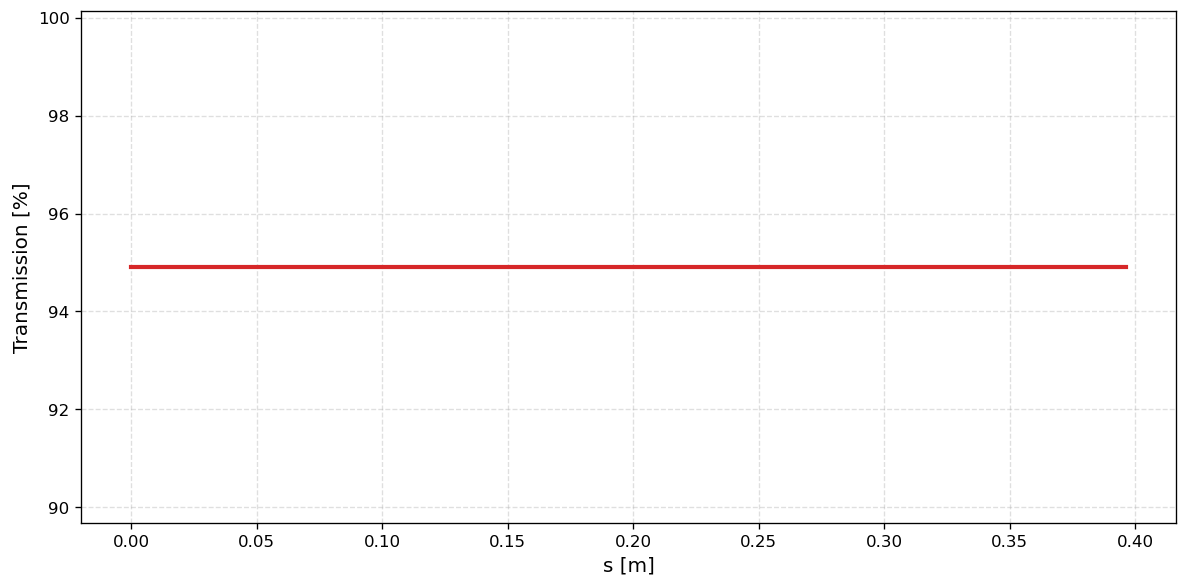

In [28]:
lebt = create_lebt(B0)
s, Bx, By, Bz, Babs = plot_solenoid_field_lattice(lebt)


B1 = lebt.track(B0)
I = B1.get_info()

M1 = B1.get_phase_space('%x %xp %y %yp %N')

x  = M1[:, 0]   # mm
xp = M1[:, 1]   # rad
y  = M1[:, 2]   # mm
yp = M1[:, 3]   # rad

N=len(x)

sigma_x_mm = np.std(x)
sigma_y_mm = np.std(y)

sigma_xp_mrad = np.std(xp) * 1e3
sigma_yp_mrad = np.std(yp) * 1e3

print("RF-Track final values")
print("---------------------")

print("\nX-X'")
print(f"emit_x      = {I.emitt_x:.6f} mm mrad")
print(f"Twiss beta_x = {I.beta_x:.6f} mm/mrad")
print(f"Twiss alpha_x = {I.alpha_x:.6f}")
print(f"sigma_x     = {sigma_x_mm:.6f} mm")
print(f"sigma_xp    = {sigma_xp_mrad:.6f} mrad")

print("\nY-Y'")
print(f"emit_y      = {I.emitt_y:.6f} mm mrad")
print(f"Twiss beta_y = {I.beta_y:.6f} mm/mrad")
print(f"Twiss alpha_y = {I.alpha_y:.6f}")
print(f"sigma_y     = {sigma_y_mm:.6f} mm")
print(f"sigma_yp    = {sigma_yp_mrad:.6f} mrad")

print("\n4D")
print(f"emit4D      = {I.emitt_4d**2:.6e} (mm mrad)^2")



#plot_phase_space(x, xp, "x [mm]", "x' [rad]")
#plot_phase_space(y,yp,"y [mm]", "y' [rad]")
#plot_phase_space(x, y,  "x [mm]", "y [mm]")
#plot_phase_space(xp, yp, "x' [mm]", "y' [rad]")


T = lebt.get_transport_table('%S %sigma_x %sigma_y %N %mean_P %beta_x %beta_y %beta_z %alpha_x %alpha_y %alpha_z %mean_E %sigma_px %sigma_py')

s  = T[:, 0]
mx = T[:, 1]
my = T[:, 2]
#N  = T[:, 3]
N = np.full_like(mx,N)
P = T[:, 4]
beta_x = T[:, 5]
beta_y = T[:, 6]
beta_z = T[:, 7]
alpha_x = T[:, 8]
alpha_y = T[:, 9]
alpha_z = T[:, 10]
E_total = T[:, 11]          
sigma_px = T[:, 12]
sigma_py = T[:, 13]
mass_rf = 11174.9           
E = E_total - mass_rf     

# Save transport data to a text file
out_file = Path("rftrack_lebt_transport.txt")

data = np.column_stack((s, mx, my, N, P, beta_x, beta_y, beta_z, alpha_x, alpha_y, alpha_z, E, sigma_px, sigma_py))

np.savetxt(
    out_file,
    data,
    header="S[m] sigma_x[mm] sigma_y[mm] N mean_P[MeV/c] beta_x[mm/mrad] beta_y[mm/mrad] beta_z[mm/mrad] alpha_x[mrad] alpha_y[mrad] alpha_z[mrad] mean_E[MeV] sigma_px[mrad] sigma_py[mrad] ",
    fmt="%.10e"
)

results_dir = Path.cwd().resolve().parent / "beam_plots"
results_dir.mkdir(parents=True, exist_ok=True)

# Plot rms 
fig, ax = plt.subplots(figsize=(10, 5), dpi=120)
color_x = 'tab:blue'
color_y = 'tab:red'
ax.plot(s,  mx,  color=color_x, linewidth=2.5, linestyle='-',  label=r'$\sigma_x$')
ax.plot(s, -mx,  color=color_x, linewidth=1.8, linestyle='-')
ax.plot(s,  my,  color=color_y, linewidth=2.5, linestyle='-',  label=r'$\sigma_y$')
ax.plot(s, -my,  color=color_y, linewidth=1.8, linestyle='-')
ax.set_xlabel('s [m]', fontsize=12)
ax.set_ylabel(r'$\sigma_{x,y}$ [mm]')


ax.set_ylim(-max(mx)*1.2, max(mx)*1.2)

ax.legend(loc='upper left') 
ax.grid(True, linestyle='--', alpha=0.4)

#plot_lattice(ax)

plt.tight_layout()
fig.savefig(results_dir / "rftrack_lebt_lattice.png", bbox_inches="tight")
plt.show()

#Plot transmission

plt.figure(figsize=(10, 5), dpi=120)
plt.plot(s, N/15673*100, color='tab:red', linewidth=2.5, linestyle='-', label='Transmission')
plt.xlabel('s [m]', fontsize=12)
plt.ylabel('Transmission [%]', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig(results_dir / "rftrack_lebt_transmission.png", bbox_inches="tight")
plt.show()